# 03 - Exploratory Analysis

Explore the clean AMR gene matrix: how common is resistance, which genes
are linked to it, and whether resistant and susceptible genomes look different.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.home() / "amr-project"
PROC = ROOT / "data" / "processed"
FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

X = pd.read_csv(PROC / "gene_matrix_clean.csv", index_col=0, dtype={"genome_id": str})
y = pd.read_csv(PROC / "labels_clean.csv", index_col=0, dtype={"genome_id": str})
X.index = X.index.astype(str)
y.index = y.index.astype(str)

assert (X.index == y.index).all()
print("Gene matrix:", X.shape, " Labels:", y.shape)

Gene matrix: (2411, 543)  Labels: (2411, 3)


Percent resistant:
ceftriaxone      83.0
ciprofloxacin    76.4
gentamicin       41.6
dtype: float64

Genomes by number of drugs resistant to (0-3):
0    393
1    144
2    921
3    953
Name: count, dtype: int64

Correlation between drug labels:
               ceftriaxone  ciprofloxacin  gentamicin
ceftriaxone           1.00           0.78        0.36
ciprofloxacin         0.78           1.00        0.38
gentamicin            0.36           0.38        1.00


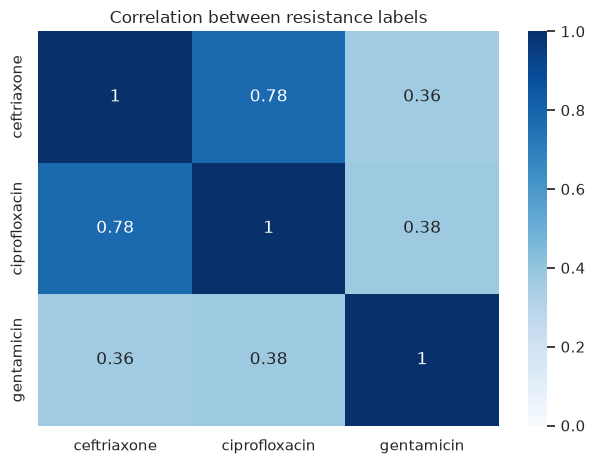

In [2]:
prev = (y.mean() * 100).round(1)
print("Percent resistant:")
print(prev)

n_res = y.sum(axis=1).astype(int)
print("\nGenomes by number of drugs resistant to (0-3):")
print(n_res.value_counts().sort_index())

corr = y.corr()
print("\nCorrelation between drug labels:")
print(corr.round(2))

sns.heatmap(corr, annot=True, cmap="Blues", vmin=0, vmax=1)
plt.title("Correlation between resistance labels")
plt.tight_layout()
plt.savefig(FIG / "label_correlation.png", dpi=150)
plt.show()

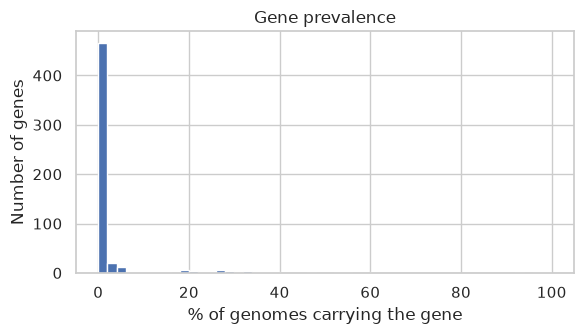

Genes before: 543  after filtering: 102
Removed: 440 rare, 1 near-universal


In [3]:
gene_prev = X.mean()

plt.figure(figsize=(6, 3.5))
plt.hist(gene_prev * 100, bins=50)
plt.xlabel("% of genomes carrying the gene")
plt.ylabel("Number of genes")
plt.title("Gene prevalence")
plt.tight_layout()
plt.savefig(FIG / "gene_prevalence.png", dpi=150)
plt.show()

keep = (gene_prev >= 0.01) & (gene_prev <= 0.99)
X_f = X.loc[:, keep]
print(f"Genes before: {X.shape[1]}  after filtering: {X_f.shape[1]}")
print(f"Removed: {(gene_prev < 0.01).sum()} rare, {(gene_prev > 0.99).sum()} near-universal")

X_f.to_csv(PROC / "gene_matrix_filtered.csv")

In [4]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

rows = []
for drug in y.columns:
    yy = y[drug].astype(int)
    for g in X_f.columns:
        x = X_f[g]
        a = int(((x == 1) & (yy == 1)).sum())   # gene present, resistant
        b = int(((x == 1) & (yy == 0)).sum())   # gene present, susceptible
        c = int(((x == 0) & (yy == 1)).sum())   # gene absent, resistant
        d = int(((x == 0) & (yy == 0)).sum())   # gene absent, susceptible
        _, p = fisher_exact([[a, b], [c, d]])
        odds = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))
        rows.append({"drug": drug, "gene": g, "n_present": a + b,
                     "pct_resistant_with_gene": round(100 * a / (a + b), 1),
                     "log2_OR": np.log2(odds), "p": p})

assoc = pd.DataFrame(rows)
assoc["q"] = multipletests(assoc["p"], method="fdr_bh")[1]
assoc.to_csv(PROC / "gene_associations.csv", index=False)

sig = assoc[assoc["q"] < 0.05]
print("Significant gene-drug pairs (q < 0.05):", len(sig))

for drug in y.columns:
    print(f"\n=== {drug}: top genes linked to resistance ===")
    top = (sig[(sig["drug"] == drug) & (sig["log2_OR"] > 0)]
           .sort_values("log2_OR", ascending=False).head(8))
    print(top[["gene", "n_present", "pct_resistant_with_gene", "log2_OR", "q"]]
          .round(3).to_string(index=False))

Significant gene-drug pairs (q < 0.05): 269

=== ceftriaxone: top genes linked to resistance ===
              gene  n_present  pct_resistant_with_gene  log2_OR   q
ompK35_G208VfsTer5        550                    100.0    8.283 0.0
  nfsB_K130QfsTer5        529                    100.0    8.206 0.0
          blaKPC-2        486                    100.0    8.042 0.0
       blaCTX-M-15       1345                     99.8    7.889 0.0
    ompK36_D135DGD        372                    100.0    7.552 0.0
         gyrA_D87N        803                     99.9    7.513 0.0
         parC_S80I       1477                     99.3    6.710 0.0
         gyrA_S83I       1283                     99.4    6.377 0.0

=== ciprofloxacin: top genes linked to resistance ===
              gene  n_present  pct_resistant_with_gene  log2_OR   q
         parC_S80I       1477                     99.8    9.346 0.0
ompK35_G208VfsTer5        550                    100.0    8.926 0.0
  nfsB_K130QfsTer5        529   

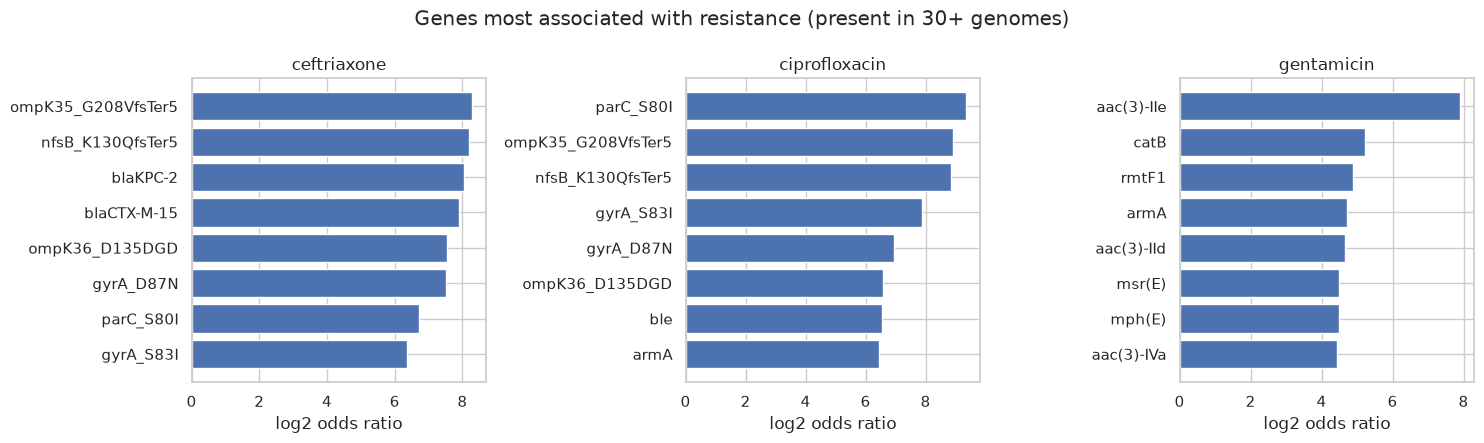

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, drug in zip(axes, y.columns):
    top = (sig[(sig["drug"] == drug) & (sig["log2_OR"] > 0) & (sig["n_present"] >= 30)]
           .sort_values("log2_OR", ascending=False).head(8)[::-1])
    ax.barh(top["gene"], top["log2_OR"])
    ax.set_title(drug)
    ax.set_xlabel("log2 odds ratio")
plt.suptitle("Genes most associated with resistance (present in 30+ genomes)")
plt.tight_layout()
plt.savefig(FIG / "top_genes_per_drug.png", dpi=150)
plt.show()

Variance explained by PC1 and PC2: [21.4 14.3]


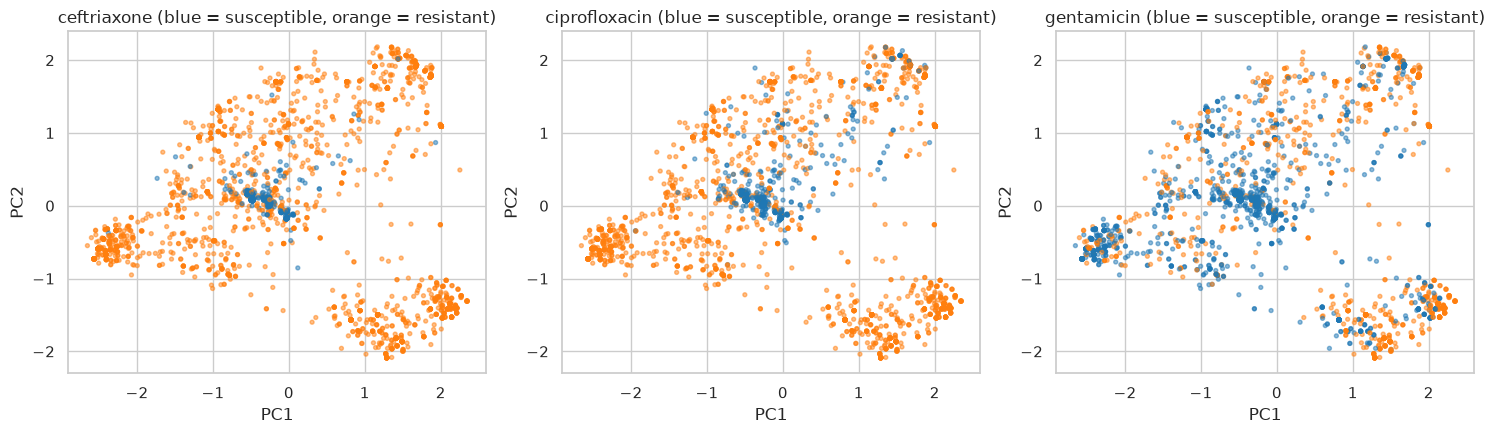

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(X_f.values)
print("Variance explained by PC1 and PC2:", (pca.explained_variance_ratio_ * 100).round(1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, drug in zip(axes, y.columns):
    ax.scatter(coords[:, 0], coords[:, 1], c=y[drug].map({0.0: "tab:blue", 1.0: "tab:orange"}),
               s=8, alpha=0.5)
    ax.set_title(f"{drug} (blue = susceptible, orange = resistant)")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig(FIG / "pca_by_drug.png", dpi=150)
plt.show()

## Summary

**Resistance is common and clustered.** 83.0% of genomes are ceftriaxone-resistant,
76.4% ciprofloxacin-resistant and 41.6% gentamicin-resistant. 953 genomes are
resistant to all three drugs and 393 to none. Ceftriaxone and ciprofloxacin labels
are strongly correlated (r = 0.78). The dataset is enriched for clinical isolates,
so these figures do not represent *K. pneumoniae* in the general population.

**Gene filtering.** Of 543 genes, 440 occur in under 1% of genomes and one is
near-universal. The remaining 102 are kept (`gene_matrix_filtered.csv`).
The filter uses no labels, so it does not leak information into modelling.

**Associations.** Fisher exact tests with Benjamini-Hochberg correction found 269
significant gene-drug pairs (`gene_associations.csv`). The strongest signals match
known mechanisms: gyrA/parC mutations for ciprofloxacin, blaCTX-M-15 and blaKPC-2
for ceftriaxone, and aac(3) enzymes and 16S rRNA methyltransferases (armA, rmtF1)
for gentamicin. Some top hits (ompK35/ompK36 and nfsB mutations) are not direct
mechanisms but co-occur with multidrug-resistant lineages, so these are
associations, not causal effects.

**PCA.** PC1 and PC2 explain 35.7% of variance. Susceptible genomes form a tight
central cluster for ceftriaxone and ciprofloxacin, while gentamicin shows more
overlap, suggesting it will be harder to predict.

**Next.** Notebook 04 trains and compares classifiers for each drug.